In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
from sympy import symbols, gamma, Rational, exp, simplify, Integer, integrate, solve, pi, expand, sqrt, oo, erf
from spb import plot3d_parametric_surface, PB, plot

# $\chi^2$ Distribution

In [7]:
from scipy.stats import chi2

## Introduction

A **chi-square random variable** is a non-negative random variable that is the sum of the squares of $k$ independent **standard normal random variables** ($Z\sim\mathcal{N}(0, 1)$), represented as 
$$X^{2}=Z_{1}^{2}+Z_{2}^{2}+\dots +Z_{k}^{2}.$$
It is characterized by a single parameter, the **degrees of freedom** ($df$), which is equal to $k$. 

## Distribution

### Probability Density Function (`.pdf`)

#### Introduction

The probability density function (pdf) of the chi-squared distribution is
$$f(x, k) = \left\{\begin{matrix}
\frac{x^{k/2-1}e^{-x/2}}{2^{k/2}\Gamma \big(\frac{k}{2}\big)}, & x > 0 \\
 0, &  \text{otherwise}\\
\end{matrix}\right.$$

In [73]:
x, y = symbols('x y', real=True, positive=True)
k = symbols('k', real=True, positive=True, integer=True)
pdf = x**(k*Rational(1,2)-Integer(1)) * \
    exp(-x*Rational(1,2))/ \
        (2**(k*Rational(1,2))*gamma(k*Rational(1,2)))
pdf

x**(k/2 - 1)*exp(-x/2)/(2**(k/2)*gamma(k/2))

In [74]:
xValue = 9
df = 7
display(pdf)
print(chi2.pdf(xValue, df=df), 
      pdf.subs([(x, xValue), (k, df)]).evalf(), 
      pdf.evalf(subs={x: xValue, k: df}))

x**(k/2 - 1)*exp(-x/2)/(2**(k/2)*gamma(k/2))

0.07179594427339576 0.0717959442733957 0.0717959442733957


#### Connection to the Gamma Distribution

In [87]:
alpha, beta, theta = symbols('alpha beta theta', real=True, positive=True, rational=True)

pdfGamma = beta**alpha * x**(alpha-Integer(1)) * exp(-beta*x)/gamma(alpha)
pdfGamma

beta**alpha*x**(alpha - 1)*exp(-beta*x)/gamma(alpha)

In [91]:
pdfGammaTheta = pdfGamma.subs([(beta, 1/theta)])

In [98]:
pdfGammaTheta.evalf(subs={theta:Integer(2), alpha: k*Rational(1, 2)})

x**(0.5*k - 1.0)*exp(-x/2)/(2.0**(0.5*k)*gamma(k/2))

In [100]:
print(simplify(pdf/pdfGammaTheta.evalf(subs={alpha: k*Rational(1, 2), theta:2})))

2.0**(0.5*k)/2**(k/2)


In [101]:
simplify(2**(k/2)/2**(k/2))

1

### Cumulative Distribution Function (`.cdf`)

In [102]:
# Compute the indefinite integral of the expression f with respect to x
cdf = integrate(pdf, (x, 0, y))
simplify(cdf)

lowergamma(k/2, y/2)/gamma(k/2)

In [106]:
# gamma.cdf(4, a=a, scale=1/b)
xValue = 9
df=7
display(cdf)
print(chi2.cdf(xValue, df=df), 
      cdf.evalf(subs={y: xValue, k:df}))

k*lowergamma(k/2, y/2)/(2*gamma(k/2 + 1))

0.7473439535034361 0.747343953503436


In [103]:
# Calculate CDF at a specific value
cdf_at_6 = chi2.cdf(6, df=df)
print(f"CDF at x=6: {cdf_at_6}")

CDF at x=6: 0.4602506496044429


### Quantiles (`.ppf`)

In [ ]:
p0 = symbols('p0', real=True, positive=True)
ppf = simplify(solve(cdf-p0, y)[0])
print(ppf)

In [6]:
# Calculate PPF (quantile function)
# This finds the value x for which the CDF is equal to a given probability
ppf_value = chi2.ppf(0.95, df=df)
print(f"95th percentile: {ppf_value}")

95th percentile: 14.067140449340169


### Mean or expected value (`.mean`)

In [110]:
mean = simplify(integrate(pdf*x, (x, 0, oo)))
mean

k

In [111]:
df=7
display(mean)
print(chi2.mean( df=df), 
      mean.evalf(subs={y: xValue, k:df}))

k

7.0 7.00000000000000


### Variances (`.var`) and Standard Deviation (`.std`)

In [113]:
var = simplify(integrate(pdf*(x-mean)**2, (x, 0, oo)))
var

2*k

In [114]:
display(var)
print(chi2.var( df=df), 
      var.evalf(subs={y: xValue, k:df}))

2*k

14.0 14.0000000000000


In [115]:
std = simplify(sqrt(var))
std

sqrt(2)*sqrt(k)

In [116]:
display(std)
print(chi2.std( df=df), 
      std.evalf(subs={y: xValue, k:df}))

sqrt(2)*sqrt(k)

3.7416573867739413 3.74165738677394


## Unbiased Sample Variance and Chi-square distribution

For a random samples of normal distribution

$$\frac{(n-1)s_n^2}{\sigma^2} \sim \chi_{n-1}^2,$$

where 
\begin{equation*}
s_n^2 = \frac{1}{n-1}\sum_{k=1}^n (X_k - \bar{X})^2
\end{equation*}

## Visualization

### Histplot

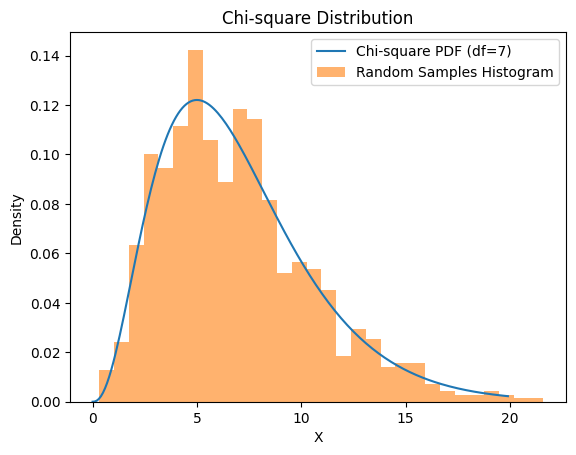

In [26]:
df = 7
# Generate random deviates using scipy.stats
random_deviates = chi2.rvs(df=df, size=1000)

# Calculate PDF at specific values
x_values = np.arange(0, 20, 0.1)
pdf_values = chi2.pdf(x_values, df=df)

# Plotting the PDF and a histogram of generated samples
plt.plot(x_values, pdf_values, label=f'Chi-square PDF (df={df})')
plt.hist(random_deviates, bins=30, density=True, alpha=0.6, label='Random Samples Histogram')
plt.title('Chi-square Distribution')
plt.xlabel('X')
plt.ylabel('Density')
plt.legend()
plt.show()

Chi squared is a continuous, right-skewed distribution, always $\geq0$, with $k$ degrees of freedom.

### Degree of Freedom

In [123]:
x_values = np.arange(0, 40, 0.1)
data = pd.DataFrame({'x': x_values})
for degreeFreedom in np.arange(5, 21):
    data[degreeFreedom]=chi2.pdf(x_values, df=degreeFreedom)
    
chi_df = pd.melt(data, id_vars=['x'], value_vars=list(np.arange(5, 21)), var_name="degree_of_freedom", value_name="pdf")

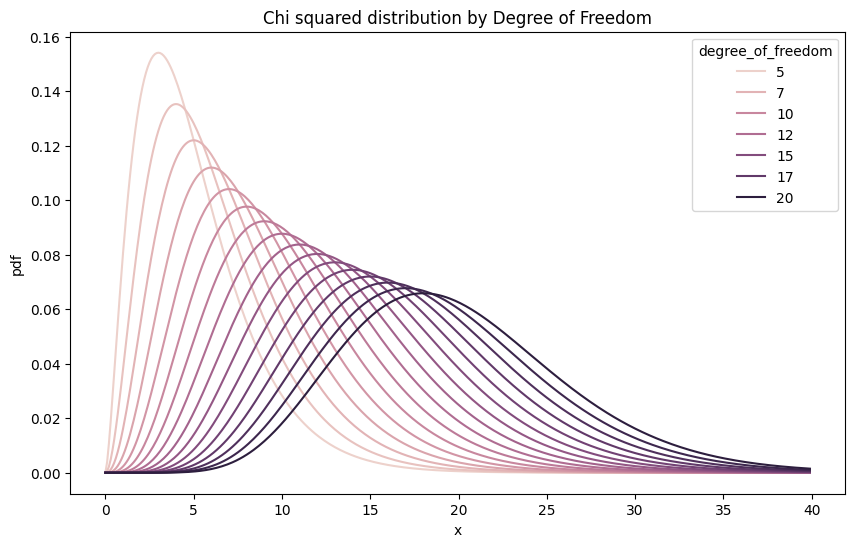

In [124]:
# Plotting 'pdf' over 'x' for each 'degree_of_freedom'
plt.figure(figsize=(10, 6))
sns.lineplot(data=chi_df, x="x", y="pdf", hue="degree_of_freedom")

plt.title("Chi squared distribution by Degree of Freedom")
plt.show()

- The shape of the distribution is determined by this parameter, which represents the number of independent variables summed.

- The distribution is non-negative and highly right-skewed, particularly with fewer degrees of freedom. As the degrees of freedom increase, it approaches a normal distribution.

# References

- [Why is the sample variance distributed with n-1 degrees of freedom?](https://towardsdatascience.com/why-is-the-sample-variance-distributed-with-n-1-degrees-of-freedom-c9edcdada28b)
- [NOTES ON STATISTICS, PROBABILITY and MATHEMATICS](https://rinterested.github.io/statistics/chi_square.html)